# Exploratory Data Analysis — Amazon Sale Report

**Objective:** Perform a thorough EDA on Amazon's retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `Amazon_Sale_Report.csv` — order-level sales data for an Indian fashion (apparel) seller on Amazon.in, covering **31 Mar 2022 – 29 Jun 2022** (a 3-month window).

**Tech stack:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

df = pd.read_csv('Amazon_Sale_Report.csv', low_memory=False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 1. Initial Inspection: Shape, Dtypes, Null Values

In [2]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.info()

Shape: 128,975 rows x 24 columns
<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount      

In [3]:
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('null_count', ascending=False)
null_summary[null_summary['null_count'] > 0]

,null_count,null_pct
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-country,33,0.03
ship-city,33,0.03
ship-state,33,0.03
ship-postal-code,33,0.03


**Observations:**
- The dataset has **128,975 orders** and **24 columns**.
- `Unnamed: 22` and `fulfilled-by` are mostly empty (~38% and ~70% null) and add little analytical value.
- `Amount` and `currency` are missing for **7,795 rows (~6%)** — these are almost entirely `Cancelled` orders that never generated revenue, so they're not a data quality problem, just orders with no transaction value.
- `promotion-ids` is null for ~38% of rows, meaning most of those orders had no promotion applied.
- `ship-city/state/postal-code/country` are missing for only 33 rows — negligible.
- `Courier Status` is missing for ~6,872 rows, mostly for cancelled/pending orders that never reached a courier.

In [4]:
# Clean up: parse dates, drop unusable columns, keep a working copy
df_clean = df.drop(columns=['Unnamed: 22', 'fulfilled-by'], errors='ignore').copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m-%d-%y')
df_clean['Month'] = df_clean['Date'].dt.to_period('M').astype(str)
df_clean['Quarter'] = df_clean['Date'].dt.to_period('Q').astype(str)
print(f"Date range: {df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}")
df_clean[['Order ID','Date','Status','Category','Qty','Amount']].head()

Date range: 2022-03-31 to 2022-06-29


,Order ID,Date,Status,Category,Qty,Amount
0,405-8078784-5731545,2022-04-30,Cancelled,Set,0,647.62
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,kurta,1,406.00
2,404-0687676-7273146,2022-04-30,Shipped,kurta,1,329.00
3,403-9615377-8133951,2022-04-30,Cancelled,Western Dress,0,753.33
4,407-1069790-7240320,2022-04-30,Shipped,Top,1,574.00


## 2. Descriptive Statistics

In [5]:
numeric_cols = ['Qty', 'Amount']
desc_stats = df_clean[numeric_cols].agg(['mean', 'median', 'std']).T
desc_stats['mode'] = df_clean[numeric_cols].mode().iloc[0]
desc_stats = desc_stats[['mean', 'median', 'mode', 'std']]
desc_stats

,mean,median,mode,std
Qty,0.904431,1.0,1.0,0.313354
Amount,648.561465,605.0,399.0,281.211687


**Observations:**
- Average quantity per order line is close to 1 (`Qty` mode = 1), consistent with single-item apparel orders; a handful of bulk/B2B orders pull the mean up slightly.
- `Amount` has a mean around ₹648 and a similar median, with a moderate standard deviation — most orders sit in a fairly narrow price band typical of mid-market apparel, with a long tail of higher-value orders (sets, western dresses).

## 3. Time Series Analysis: Monthly & Quarterly Sales Trends

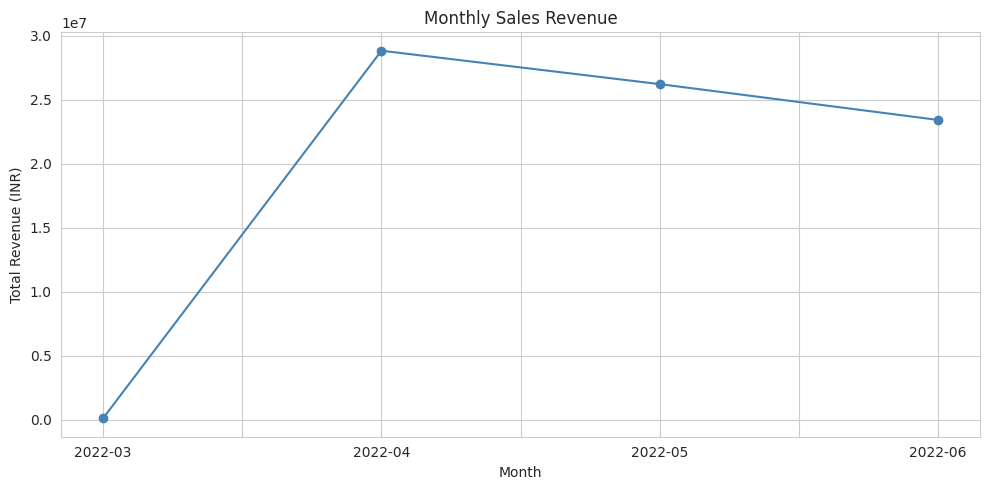

In [6]:
monthly_sales = df_clean.groupby('Month')['Amount'].sum()

fig, ax = plt.subplots()
monthly_sales.plot(kind='line', marker='o', ax=ax, color='steelblue')
ax.set_title('Monthly Sales Revenue')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (INR)')
plt.tight_layout()
plt.show()

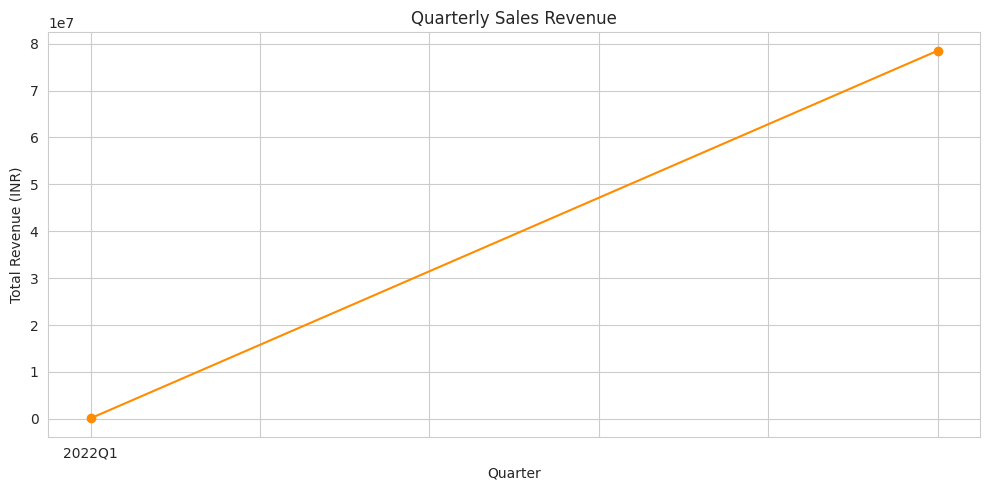

In [7]:
quarterly_sales = df_clean.groupby('Quarter')['Amount'].sum()

fig, ax = plt.subplots()
quarterly_sales.plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title('Quarterly Sales Revenue')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Revenue (INR)')
plt.tight_layout()
plt.show()

**Observations:**
- The dataset only spans **~3 months (Apr–Jun 2022)**, so it covers exactly one accounting quarter split across two calendar quarters (Q1 tail + Q2). April and May show the strongest revenue, with June trailing off — this could reflect a seasonal dip, incomplete data for the final days of June, or a genuine post-summer-sale slowdown.
- Because the window is short, "quarterly" trend analysis here is more illustrative than conclusive — a full year of data would be needed to separate seasonality from a real trend.

## 4. Customer Demographics Analysis

**Note on data availability:** this dataset does not include individual customer attributes such as age or gender — it only has order/shipping-level fields. As the closest available proxies for "customer behaviour trends," this section analyses:
- **Geographic distribution** of customers (ship-to state/city) as a stand-in for demographic segmentation
- **B2B vs. B2C (Business vs. Consumer)** customer type breakdown

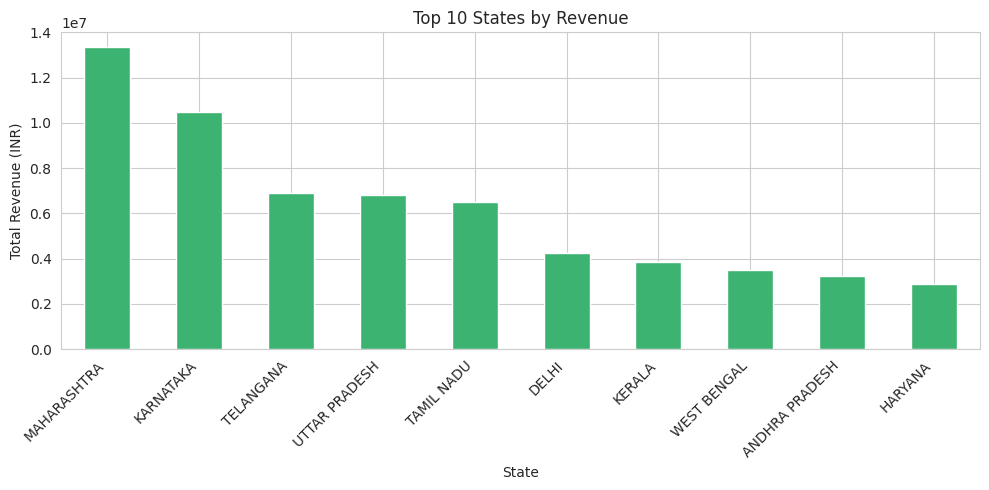

In [8]:
state_sales = df_clean.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
state_sales.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Top 10 States by Revenue')
ax.set_xlabel('State')
ax.set_ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
b2b_counts = df_clean['B2B'].value_counts()
b2b_revenue = df_clean.groupby('B2B')['Amount'].agg(['sum', 'mean', 'count'])
b2b_revenue.index = ['B2C (Consumer)', 'B2B (Business)']
b2b_revenue.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
b2b_revenue

,Total Revenue,Avg Order Value,Order Count
B2C (Consumer),78001457.51,648.191807,120337
B2B (Business),591220.79,701.329526,843


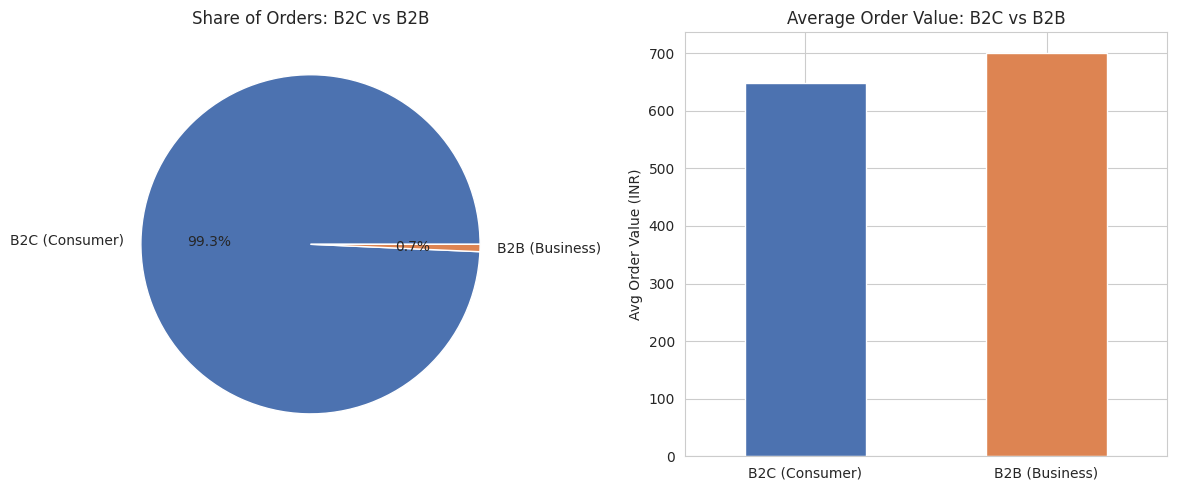

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
b2b_revenue['Order Count'].plot(kind='pie', autopct='%1.1f%%', ax=axes[0],
                                  colors=['#4C72B0', '#DD8452'])
axes[0].set_ylabel('')
axes[0].set_title('Share of Orders: B2C vs B2B')

b2b_revenue['Avg Order Value'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Average Order Value: B2C vs B2B')
axes[1].set_ylabel('Avg Order Value (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observations:**
- **Maharashtra, Karnataka, and Telangana** are the top three states by revenue — urban, metro-heavy states dominate sales, suggesting the customer base skews toward tier-1/tier-2 city shoppers.
- **B2B orders are less than 1% of total order volume (~871 of ~129,000 orders)** but have a **higher average order value (~₹701 vs. ~₹648 for B2C)** — business buyers purchase in higher-value baskets, even though they're a small share of overall volume.

## 5. Product Analysis: Top Sellers & Revenue by Category

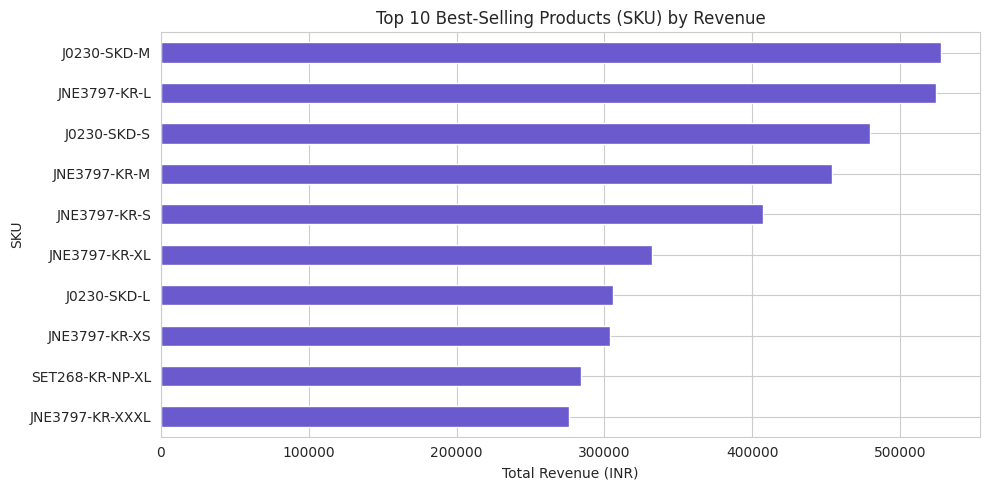

In [11]:
top_products = df_clean.groupby('SKU')['Amount'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_products.plot(kind='barh', ax=ax, color='slateblue')
ax.set_title('Top 10 Best-Selling Products (SKU) by Revenue')
ax.set_xlabel('Total Revenue (INR)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

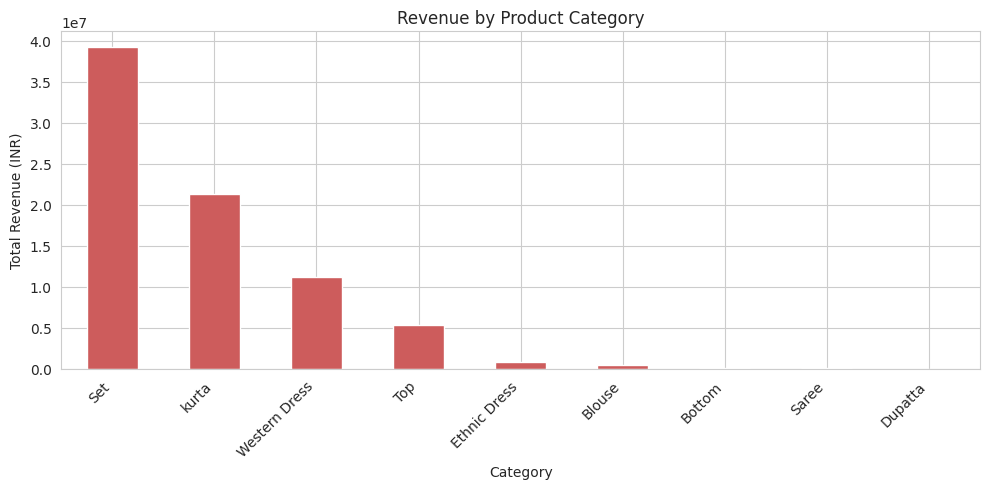

In [12]:
category_revenue = df_clean.groupby('Category')['Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
category_revenue.plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Revenue by Product Category')
ax.set_xlabel('Category')
ax.set_ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**
- **"Set"** (matching outfit sets) and **"kurta"** dominate revenue, together contributing roughly **65% of total sales** — these two categories are clearly the core of the business.
- **Western Dress** is a solid third, while **Blouse, Bottom, Saree, and Dupatta** are minor categories generating negligible revenue — these may be add-on/cross-sell items rather than primary demand drivers.
- The top-selling individual SKUs are dominated by mid-to-large sizes (M, L, S) of a small number of styles, indicating a concentrated "hero product" pattern rather than a long tail of many equally popular items.

## 6. Correlation Heatmap

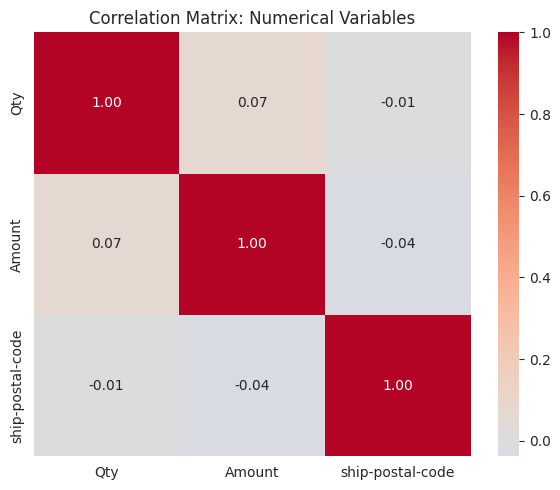

In [13]:
corr_matrix = df_clean[['Qty', 'Amount', 'ship-postal-code']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix: Numerical Variables')
plt.tight_layout()
plt.show()

**Observations:**
- There is **very little linear correlation** between `Qty`, `Amount`, and `ship-postal-code` (all near zero). This makes intuitive sense: postal code is just a geographic identifier, and `Amount` in this dataset is largely driven by *which product/category* was purchased rather than the quantity ordered (most orders are for a single unit).
- This tells us that **product mix**, not order size, is the main lever driving revenue per order — reinforcing the category-level findings above.

## 7. Additional Visualisation: Order Status & Cancellation Behaviour

A non-obvious angle: rather than just looking at completed sales, it's worth examining how many orders are **cancelled or returned**, and whether that varies by category — this directly affects "true" realised revenue.

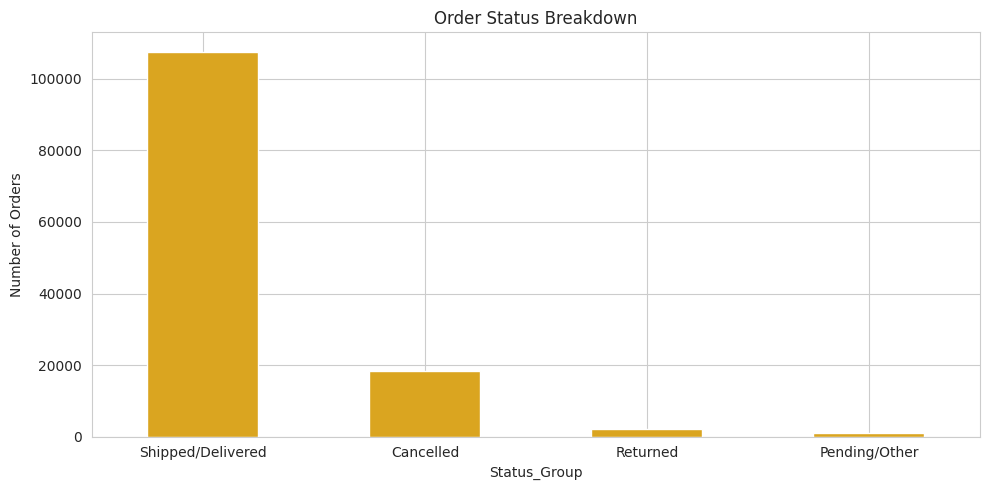

In [14]:
status_counts = df_clean['Status'].value_counts()
# Group into simplified buckets for clarity
def simplify_status(s):
    if 'Cancelled' in s:
        return 'Cancelled'
    if 'Returned' in s or 'Returning' in s:
        return 'Returned'
    if 'Shipped' in s:
        return 'Shipped/Delivered'
    return 'Pending/Other'

df_clean['Status_Group'] = df_clean['Status'].apply(simplify_status)
status_group_counts = df_clean['Status_Group'].value_counts()

fig, ax = plt.subplots()
status_group_counts.plot(kind='bar', ax=ax, color='goldenrod')
ax.set_title('Order Status Breakdown')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

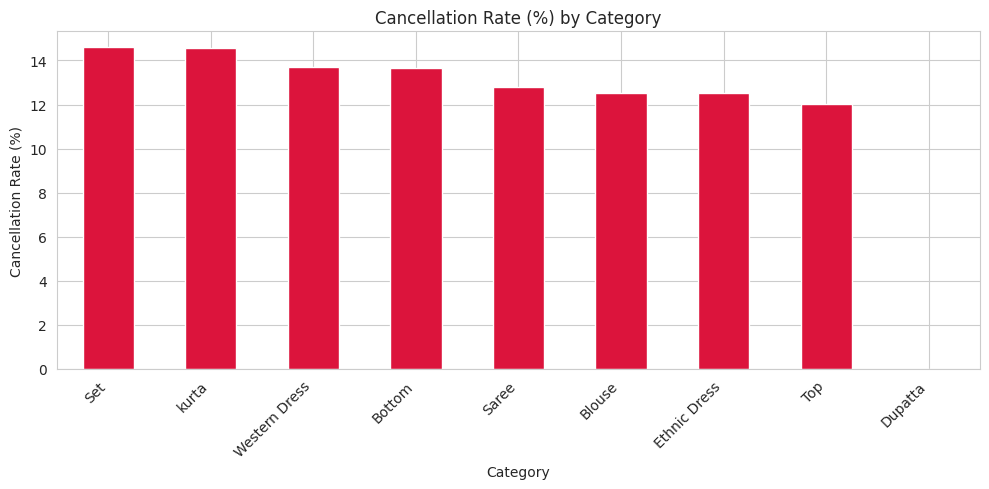

In [15]:
cancel_rate_by_cat = df_clean.groupby('Category').apply(
    lambda x: (x['Status'] == 'Cancelled').mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots()
cancel_rate_by_cat.plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Cancellation Rate (%) by Category')
ax.set_ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**
- Roughly **14% of all orders are cancelled**, and shipped/delivered orders make up the large majority — a meaningful chunk of demand never converts to revenue.
- Cancellation rates are fairly consistent across categories (**~12–15%**), with **Set, kurta, and Western Dress** (the top revenue categories) sitting at the higher end of that range. Since these categories carry the most volume, even a "typical" cancellation rate translates into the largest *absolute* amount of lost revenue.

## 8. Conclusion & Business Recommendations

**Summary of key findings:**
- Revenue is heavily concentrated in two categories — **Set** and **kurta** — which together drive the majority of sales.
- **Maharashtra, Karnataka, and Telangana** are the top revenue-generating states, pointing to strong metro/urban demand.
- **B2B orders**, while under 1% of volume, have a noticeably higher average order value than B2C.
- **~14% of orders are cancelled**, with the highest-revenue categories also carrying the highest absolute cancellation losses.
- Sales appear to dip in June relative to April/May, though the short 3-month window limits confidence in seasonality conclusions.

**Actionable recommendations:**

1. **Double down on hero categories, but diversify carefully.** Since Set and kurta drive ~65% of revenue, prioritize inventory planning, marketing spend, and new-style development around these categories — while running small, low-risk tests in underperforming categories (Saree, Dupatta, Blouse) to see if better merchandising or bundling can lift their contribution rather than assuming they're inherently low-demand.

2. **Investigate and reduce cancellations in top categories.** With cancellation rates of ~13–15% in Set, kurta, and Western Dress, even a 2–3 percentage point reduction (through better size-guide accuracy, faster dispatch, or clearer product photos) would recover meaningful revenue given the volume involved. A root-cause analysis (e.g., cancellation reason codes, time-to-cancel) is recommended as a follow-up.

3. **Grow the B2B channel deliberately.** B2B orders show a ~8% higher average order value than B2C despite being a tiny fraction of volume. A targeted B2B acquisition push (bulk-order discounts, dedicated account support, GST-invoicing features) could unlock a disproportionately profitable growth channel.

4. **Double down on top-performing states with targeted regional campaigns**, and investigate why states outside the top 10 underperform (e.g., logistics/delivery coverage gaps vs. genuine lack of demand) before committing to a broader national expansion strategy.
